# NHANES 2017–2018: Predicting Diabetes Risk from Clinical Risk Factors

**Data source:** National Health and Nutrition Examination Survey (CDC), 2017–2018 cycle  
**Tools:** Python, pandas, matplotlib, scikit-learn

---

This project uses survey data from ~9,000 U.S. adults to predict diabetes diagnosis 
from clinical and demographic risk factors — without using direct laboratory markers 
(HbA1c, fasting glucose). The goal is to identify who should be prioritised for 
diagnostic testing, using only variables available in a routine clinical assessment.

## Data Dictionary

NHANES stores variables under CDC codebook names rather than plain-English labels. Here's what each column used in this project means:

| Column | Meaning | Notes |
|---|---|---|
| `SEQN` | Respondent sequence number | Unique participant ID, used only to merge files |
| `RIDAGEYR` | Age in years at screening | Filtered to adults (18+) |
| `RIAGENDR` | Gender | Recoded to 1 = Male, 0 = Female |
| `DMDEDUC2` | Education level (adults 20+) | 1 = Less than 9th grade, 2 = 9th–11th grade, 3 = High school grad/GED, 4 = Some college/AA degree, 5 = College graduate or above |
| `INDFMPIR` | Ratio of family income to the poverty threshold | 0–5 scale; values ≥ 5 are top-coded at 5 |
| `BMXBMI` | Body Mass Index | kg/m² |
| `BMXWAIST` | Waist circumference | cm |
| `BPXSY1` | Systolic blood pressure | First reading, mm Hg |
| `BPXDI1` | Diastolic blood pressure | First reading, mm Hg |
| `LBXTC` | Total cholesterol | mg/dL |
| `DIQ010` | Survey question: "Has a doctor told you that you have diabetes?" | 1 = Yes, 2 = No (others dropped); recoded into `diabetes` below and removed |
| `diabetes` | Derived outcome variable | 1 = diagnosed with diabetes, 0 = not diagnosed |

Source: [NHANES 2017–2018 variable codebooks](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=2017).

## Part A — Data Assembly & Exploration

### A1. Load Data

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score, precision_score, 
                             f1_score, roc_auc_score, confusion_matrix)
from sklearn.metrics import roc_curve

In [117]:
demographics = pd.read_csv('NHANES_2017-2018/demographics.csv')
examination = pd.read_csv('NHANES_2017-2018/examination.csv')
laboratory = pd.read_csv('NHANES_2017-2018/laboratory.csv')
questionnaire = pd.read_csv('NHANES_2017-2018/questionnaire.csv')

In [118]:
# Check the key variables exist
print('SEQN in demographics:', 'SEQN' in demographics.columns)
print('RIDAGEYR in demographics:', 'RIDAGEYR' in demographics.columns)
print('RIAGENDR in demographics:', 'RIAGENDR' in demographics.columns)
print('DMDEDUC2 in demographics:', 'DMDEDUC2' in demographics.columns)
print('INDFMPIR in demographics:', 'INDFMPIR' in demographics.columns)

print()
print('DIQ010 in questionnaire:', 'DIQ010' in questionnaire.columns)

print()
print('BMXBMI in examination:', 'BMXBMI' in examination.columns)
print('BMXWAIST in examination:', 'BMXWAIST' in examination.columns)
print('BPXSY1 in examination:', 'BPXSY1' in examination.columns)
print('BPXDI1 in examination:', 'BPXDI1' in examination.columns)

print()
print('LBXTC in laboratory:', 'LBXTC' in laboratory.columns)

SEQN in demographics: True
RIDAGEYR in demographics: True
RIAGENDR in demographics: True
DMDEDUC2 in demographics: True
INDFMPIR in demographics: True

DIQ010 in questionnaire: True

BMXBMI in examination: True
BMXWAIST in examination: True
BPXSY1 in examination: True
BPXDI1 in examination: True

LBXTC in laboratory: True


### A2. Merge Files

In [119]:
demographics = demographics[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'INDFMPIR']]
examination = examination[['SEQN', 'BMXBMI', 'BMXWAIST', 'BPXSY1', 'BPXDI1']]
laboratory = laboratory[['SEQN', 'LBXTC']]
questionnaire = questionnaire[['SEQN', 'DIQ010']]

# Merge all on SEQN
df = demographics.merge(examination, on='SEQN', how='left') \
                 .merge(laboratory, on='SEQN', how='left') \
                 .merge(questionnaire, on='SEQN', how='left')

print(df.shape)
print(df.head())

(9254, 11)
      SEQN  RIDAGEYR  RIAGENDR  DMDEDUC2  INDFMPIR  BMXBMI  BMXWAIST  BPXSY1  \
0  93703.0       2.0       2.0       NaN      5.00    17.5      48.2     NaN   
1  93704.0       2.0       1.0       NaN      5.00    15.7      50.0     NaN   
2  93705.0      66.0       2.0       2.0      0.82    31.7     101.8     NaN   
3  93706.0      18.0       1.0       NaN       NaN    21.5      79.3   112.0   
4  93707.0      13.0       1.0       NaN      1.88    18.1      64.1   128.0   

   BPXDI1  LBXTC  DIQ010  
0     NaN    NaN     2.0  
1     NaN    NaN     2.0  
2     NaN  157.0     2.0  
3    74.0  148.0     2.0  
4    38.0  189.0     2.0  


### A3. Encode Outcome & Filter Adults

In [120]:
# Keep adults only
df = df[df['RIDAGEYR'] >= 18]

In [121]:
# Keep only diabetes yes/no (1 and 2), drop borderline/refused/don't know
df = df[df['DIQ010'].isin([1.0, 2.0])]

In [122]:
# Encode outcome: 1=diabetes, 0=no diabetes
df['diabetes'] = (df['DIQ010'] == 1.0).astype(int)
df = df.drop(columns='DIQ010')

# Encode gender: 1=Male, 0=Female
df['RIAGENDR'] = (df['RIAGENDR'] == 1).astype(int)

In [123]:
# Class distribution
print(df['diabetes'].value_counts())
print(df['diabetes'].value_counts(normalize=True).round(3) * 100)

diabetes
0    4800
1     878
Name: count, dtype: int64
diabetes
0    84.5
1    15.5
Name: proportion, dtype: float64


The dataset contains **5,678 adults** after filtering for age ≥ 18 and valid diabetes responses.

The outcome variable `diabetes` is imbalanced: **84.5% no diabetes (0)** vs **15.5% diabetes (1)**.
This means accuracy is a misleading metric — a model that predicts "no diabetes" for every patient 
would score 84.5% while being clinically useless. I will use Recall and AUC-ROC as my primary 
evaluation metrics instead.

### A4. Missing Value Audit

In [124]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df['missing_count'] > 0])

          missing_count  missing_%
DMDEDUC2            285        5.0
INDFMPIR            808       14.2
BMXBMI              411        7.2
BMXWAIST            654       11.5
BPXSY1              927       16.3
BPXDI1              927       16.3
LBXTC               666       11.7


Missing values are present across 7 features, ranging from 5.0% (education) to 16.3% 
(blood pressure). All are well below 20%, so median imputation for continuous variables 
and mode imputation for categorical variables is a safe and justified approach.

## Part B — Cleaning & Modelling Prep
### B1. Imputation

In [125]:
X = df.drop(columns=['SEQN', 'diabetes'])
y = df['diabetes']

In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [127]:
# Impute using training set statistics only
for col in ['BMXBMI', 'BMXWAIST', 'BPXSY1', 'BPXDI1', 'LBXTC', 'INDFMPIR']:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

for col in ['DMDEDUC2', 'RIAGENDR']:
    mode = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode)
    X_test[col] = X_test[col].fillna(mode)

print('Missing in X_train:', X_train.isnull().sum().sum())
print('Missing in X_test:', X_test.isnull().sum().sum())

Missing in X_train: 0
Missing in X_test: 0


All missing values have been filled using training set statistics only — medians for 
continuous variables, mode for categorical ones. No data leakage introduced.

### B2. Standardise Features

In [128]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Features are now standardised — each column has mean 0 and standard deviation 1. 
This ensures the model doesn't give unfair weight to variables with larger numerical ranges.

## Part C — Logistic Regression & Evaluation

### C1. Fit Logistic Regression

In [129]:
model = LogisticRegression(penalty='l2', max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

We fit a logistic regression model with L2 regularisation on the training set. 
L2 penalises large coefficients, reducing the risk of overfitting.

### C2. Evaluate Model

In [130]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.3f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob):.3f}')
print()
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.842
Recall:    0.148
Precision: 0.473
F1 Score:  0.225
AUC-ROC:   0.800

Confusion Matrix:
[[931  29]
 [150  26]]


**Accuracy (84.2%)** is nearly identical to always predicting "no diabetes" (84.5% baseline) — useless as a metric here.

**Recall (14.8%)** is low: the model correctly identified only 26 out of 176 diabetic patients, 
missing 150. Clinically unacceptable as a standalone screening tool.

**AUC-ROC (0.800)** tells a better story — the model has learned real patterns separating the 
two groups. The low recall is driven by the imbalanced classes suppressing predictions at the 
default 0.5 threshold, not by a failure to learn. Lowering the threshold would improve recall 
at the cost of more false positives — a deliberate clinical tradeoff.

### C3. Odds Ratios

In [131]:
odds_ratios = np.exp(model.coef_[0])
features = X.columns

odds_df = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0],
    'odds_ratio': odds_ratios
}).sort_values('odds_ratio', ascending=False)

print(odds_df)

    feature  coefficient  odds_ratio
0  RIDAGEYR     1.042910    2.837462
5  BMXWAIST     0.414288    1.513292
4    BMXBMI     0.178010    1.194837
1  RIAGENDR     0.076293    1.079279
6    BPXSY1     0.040820    1.041665
3  INDFMPIR     0.011697    1.011766
7    BPXDI1    -0.041088    0.959745
2  DMDEDUC2    -0.168623    0.844827
8     LBXTC    -0.352735    0.702763


- Age (RIDAGEYR) is the strongest predictor (OR = 2.84) - a one standard deviation increase multiplies 
the odds of diabetes by 2.84, consistent with the well-established relationship between 
age and Type 2 diabetes risk.

- Waist circumference (BMXWAIST) is second at 1.51 and outperforms BMI (OR = 1.19) as a predictor, suggesting 
abdominal obesity is more informative than overall body mass — consistent with medical 
literature on visceral fat and insulin resistance.

- Total cholesterol (LBXTC) at 0.70 shows a counterintuitive negative association. This likely 
reflects the composition of total cholesterol — high HDL ("good" cholesterol) is 
protective against diabetes and may be driving this result.

### C4. Addressing Class Imbalance — Balanced Model

In [132]:
model_balanced = LogisticRegression(penalty='l2', max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)
y_prob_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test, y_pred_balanced):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred_balanced):.3f}')
print(f'Precision: {precision_score(y_test, y_pred_balanced):.3f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_balanced):.3f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_balanced):.3f}')
print()
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy:  0.703
Recall:    0.744
Precision: 0.310
F1 Score:  0.437
AUC-ROC:   0.798

Confusion Matrix:
[[668 292]
 [ 45 131]]


- Recall jumped from 14.8% to 74.4% — the balanced model now catches 131 out of 176 diabetic 
patients instead of just 26. That's the whole point of the adjustment.

- AUC-ROC barely changed (0.800 → 0.798), confirming the underlying model learned the same 
patterns — we just shifted the decision threshold effectively.

- Precision dropped from 0.473 to 0.310, meaning more false positives. In a screening context 
this is an acceptable tradeoff — you'd rather send 292 healthy people for a follow-up blood 
test than miss 150 diabetic patients.

- **The balanced model is the clinical recommendation.** A missed diabetes diagnosis means 
delayed treatment and continued damage to the patient. A false positive means an unnecessary 
blood test — a minor inconvenience compared to the cost of missing a true case.

## Part D — Visualisations

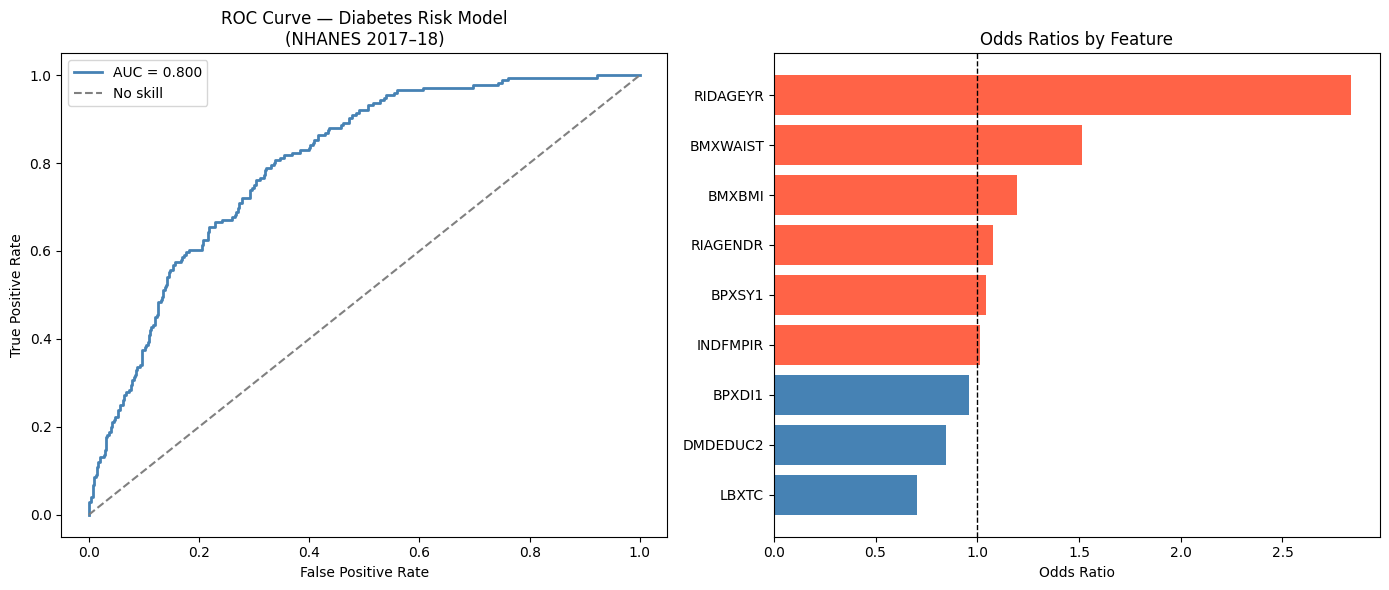

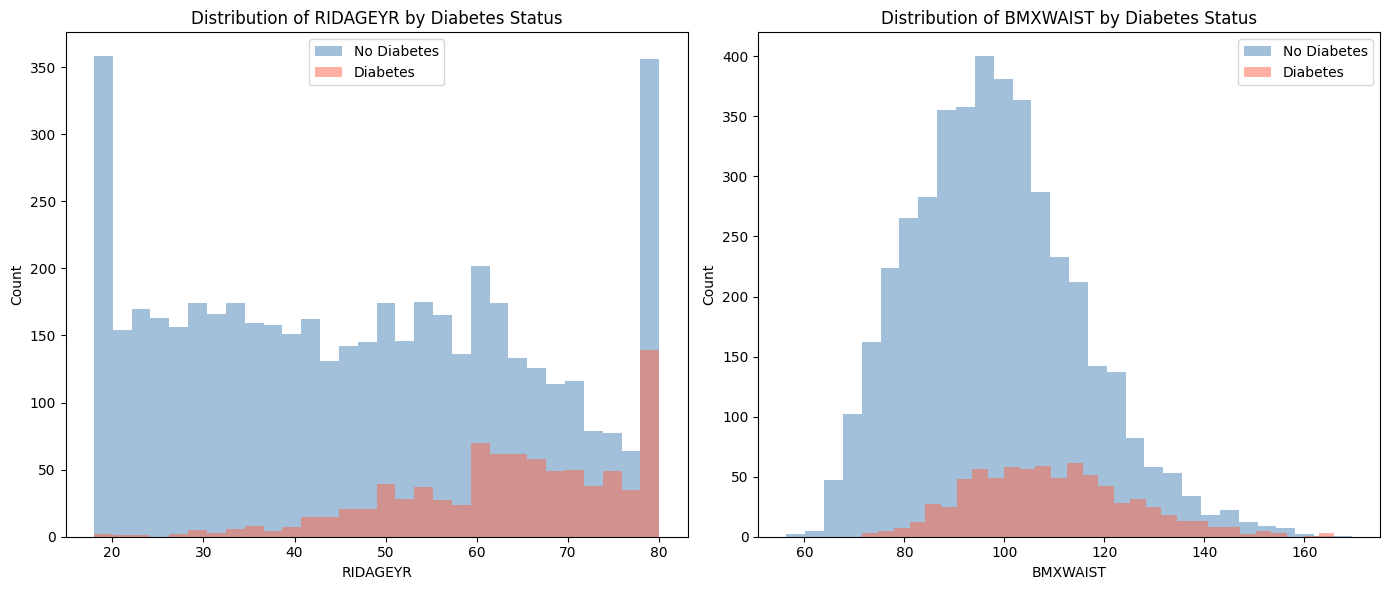

In [133]:
# Plot 1 & 2 — ROC Curve and Odds Ratios
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = 0.800')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='No skill')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Diabetes Risk Model\n(NHANES 2017–18)')
axes[0].legend()

# Plot 2 — Odds Ratio Plot
odds_df_sorted = odds_df.sort_values('odds_ratio')
colors = ['tomato' if x > 1 else 'steelblue' for x in odds_df_sorted['odds_ratio']]
axes[1].barh(odds_df_sorted['feature'], odds_df_sorted['odds_ratio'], color=colors)
axes[1].axvline(x=1, linestyle='--', color='black', linewidth=1)
axes[1].set_xlabel('Odds Ratio')
axes[1].set_title('Odds Ratios by Feature')

plt.tight_layout()
plt.show()

# Plot 3 — Risk Factor Distributions
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
for i, col in enumerate(['RIDAGEYR', 'BMXWAIST']):
    axes2[i].hist(df[df['diabetes'] == 0][col], alpha=0.5, label='No Diabetes', color='steelblue', bins=30)
    axes2[i].hist(df[df['diabetes'] == 1][col], alpha=0.5, label='Diabetes', color='tomato', bins=30)
    axes2[i].set_xlabel(col)
    axes2[i].set_ylabel('Count')
    axes2[i].set_title(f'Distribution of {col} by Diabetes Status')
    axes2[i].legend()

plt.tight_layout()
plt.show()

**ROC Curve:** The curve bows toward the top-left corner, well above the diagonal baseline 
(random guess). An AUC of 0.800 means the model correctly ranks a diabetic patient as higher 
risk than a non-diabetic patient 80% of the time.

**Odds Ratio Plot:** Age (RIDAGEYR) is the dominant predictor, followed by waist circumference 
(BMXWAIST). Features with OR > 1 (red) increase diabetes risk; features with OR < 1 (blue) 
decrease it. Total cholesterol (LBXTC) shows the strongest protective association, likely 
reflecting the role of HDL in the total cholesterol composition.

**Age Distribution:** Diabetes cases (red) are concentrated at older ages, confirming age as 
the strongest predictor. The spike at 80 is a data artefact — NHANES top-codes age at 80, 
meaning all respondents aged 80 and above are recorded as 80.

**Waist Distribution:** The diabetes group (red) is shifted right toward higher waist 
measurements, visually confirming what the odds ratio showed — abdominal obesity is a 
meaningful clinical signal for diabetes risk.

### D2. ROC Curve — Model Comparison

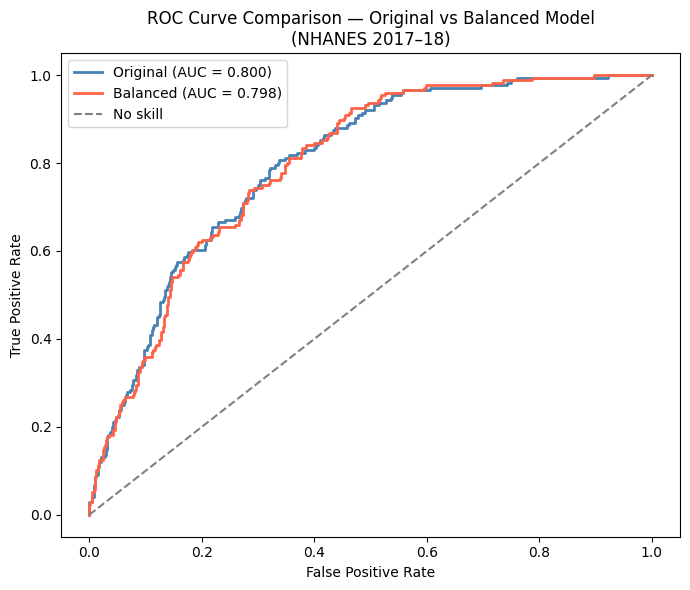

In [134]:
fig, ax = plt.subplots(figsize=(7, 6))

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, color='steelblue', lw=2, label='Original (AUC = 0.800)')

fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_balanced)
ax.plot(fpr_b, tpr_b, color='tomato', lw=2, label='Balanced (AUC = 0.798)')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='No skill')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — Original vs Balanced Model\n(NHANES 2017–18)')
ax.legend()

plt.tight_layout()
plt.show()

Both models achieve near-identical AUC scores (0.800 vs 0.798), confirming that class 
weighting improved recall without sacrificing the model's overall discriminating ability.

## Conclusion

This project used logistic regression on NHANES 2017–2018 data to predict diabetes diagnosis 
from clinical and demographic risk factors in ~5,600 U.S. adults.

**Key findings:**
- Age and waist circumference are the strongest predictors of diabetes risk, consistent with 
  established clinical literature on Type 2 diabetes.
- The model achieves an AUC-ROC of 0.800, indicating strong discriminating ability between 
  diabetic and non-diabetic patients.
- Accuracy (84.2%) is a misleading metric here — it barely exceeds the no-skill baseline of 
  84.5%. Recall (14.8%) reflects the challenge of predicting a minority class at the default 
  0.5 threshold.

**Limitations:**
- **Class imbalance:** Only 15.5% of the sample has diabetes. A balanced logistic regression 
  model was fitted to address this, improving recall from 14.8% to 74.4% at a moderate cost 
  to precision — an acceptable tradeoff for a clinical screening tool.
- **No direct lab markers:** HbA1c and fasting glucose were intentionally excluded to simulate 
  a pre-screening scenario. Including them would dramatically improve performance but defeat 
  the clinical purpose of the model.
- **Population scope:** NHANES 2017–2018 represents the U.S. adult population and may not 
  generalise to other countries or healthcare settings.